<a href="https://colab.research.google.com/github/pradhankuntal6-ship-it/AI-ML-Based-Predictive-Maintenance-and-Vehicle-Health-Monitoring-System-/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu
(27751, 12) | failure_soon rate: 9.1%


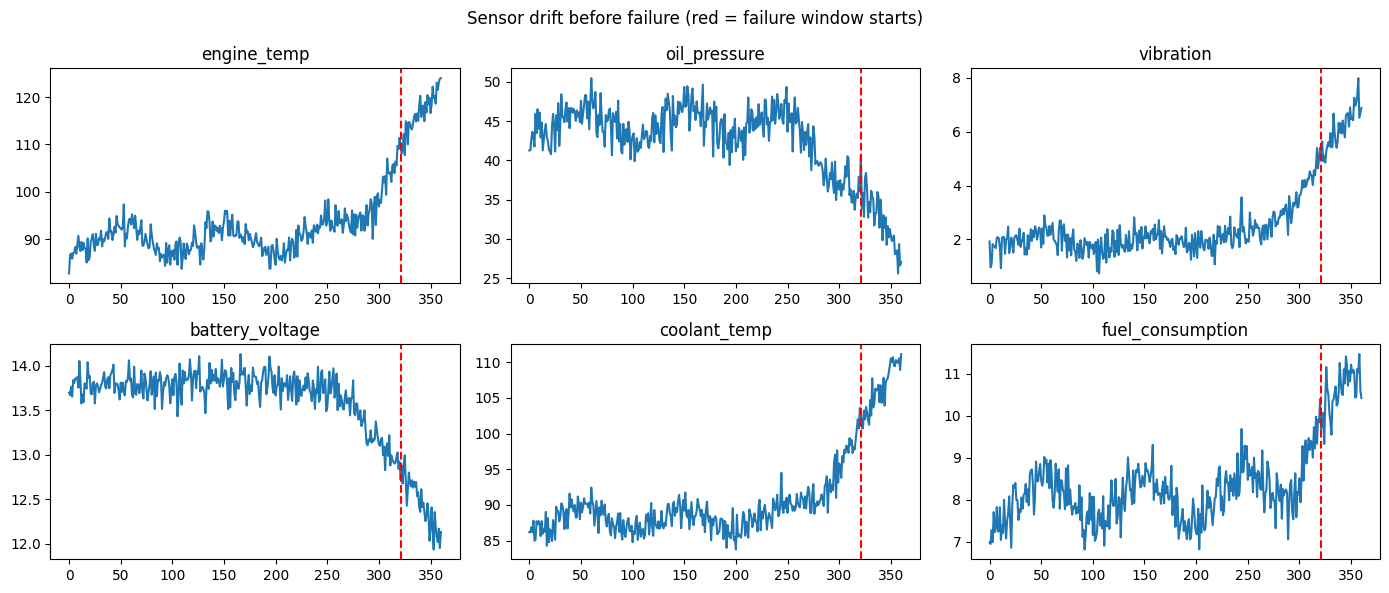

33 features
Train: (20548, 33) Test: (7203, 33)
done: Logistic Regression
done: Decision Tree
done: Random Forest
done: XGBoost
Sequences: (9421, 30, 9) (3319, 30, 9)
LSTM epoch 5/15 loss 0.0705
LSTM epoch 10/15 loss 0.0599
LSTM epoch 15/15 loss 0.0468
GRU epoch 5/15 loss 0.0576
GRU epoch 10/15 loss 0.0548
GRU epoch 15/15 loss 0.0512
Transformer epoch 5/15 loss 0.0666
Transformer epoch 10/15 loss 0.0631
Transformer epoch 15/15 loss 0.0442


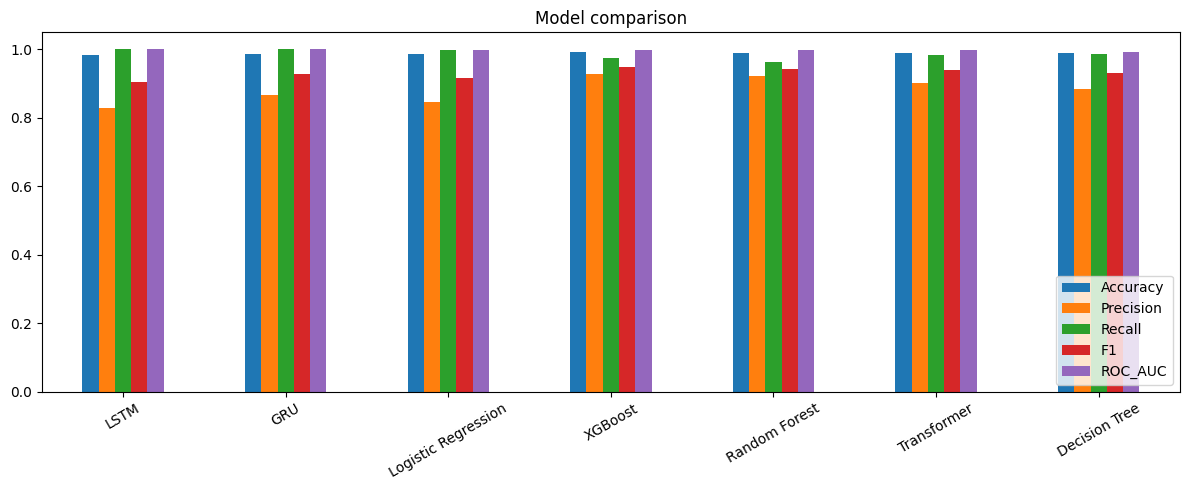

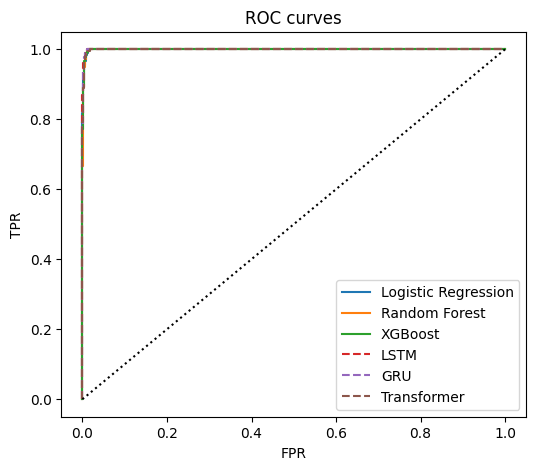

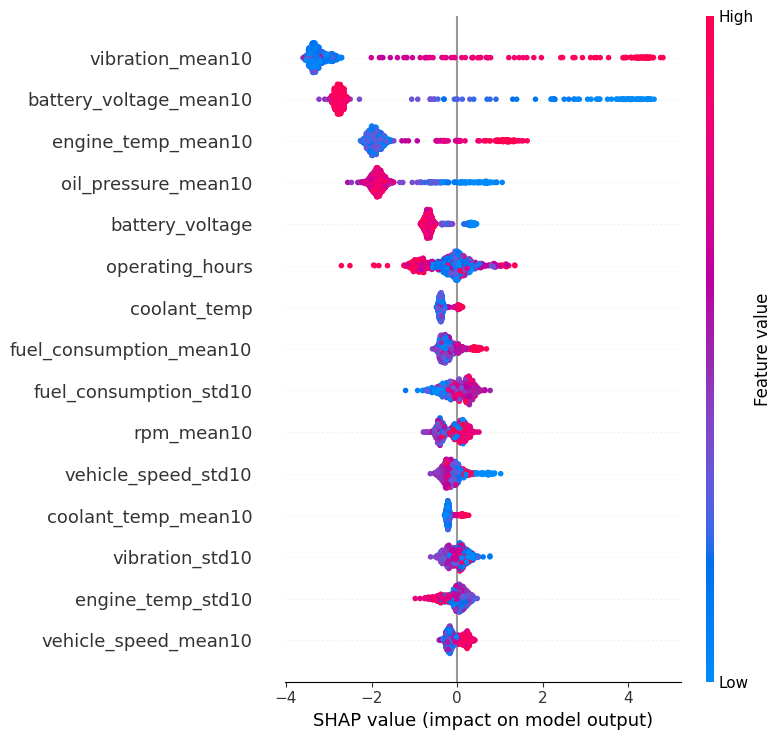


===== EARLY LIFE (step 100/361) =====
Vehicle Health: 100%
Failure Probability: 0%
Status: NORMAL
Major contributing factors:
  1. High fuel consumption
  2. Abnormal speed
  3. Abnormal oil pressure
Action: No maintenance needed.

===== APPROACHING FAILURE (step 316/361) =====
Vehicle Health: 58%
Failure Probability: 5%
Status: NORMAL
Major contributing factors:
  1. Abnormal speed
  2. Low battery voltage
  3. High vibration
Action: No maintenance needed.

===== NEAR FAILURE (step 353/361) =====
Vehicle Health: 0%
Failure Probability: 100%
Status: CRITICAL
Major contributing factors:
  1. High vibration
  2. Low battery voltage
  3. Rising temperature
Action: STOP vehicle - immediate maintenance required!


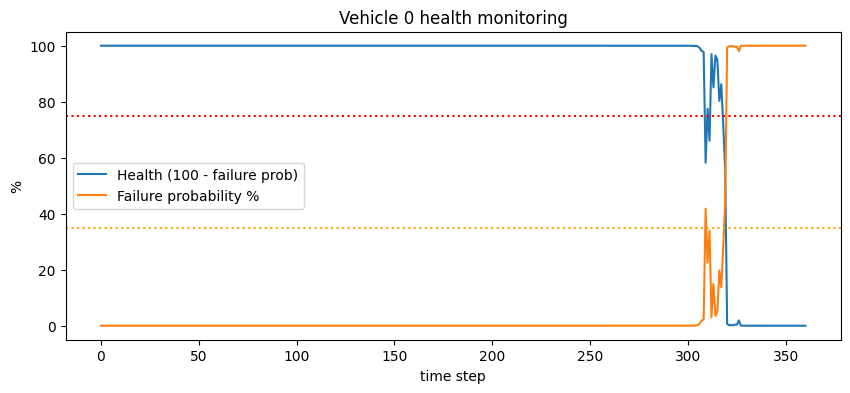

['lstm.pt', 'xgb_pipeline.joblib', 'model_comparison.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# %% [markdown]
# # AI/ML Predictive Maintenance & Vehicle Health Monitoring
# Sensors -> Preprocessing -> ML/DL Model -> Failure Probability -> Health Score -> Maintenance Alert
#
# **Models:** Logistic Regression, Decision Tree, Random Forest, XGBoost, LSTM, GRU, Transformer  |  **XAI:** SHAP
#
# Run all cells top to bottom (Runtime > Run all). A GPU is optional.

# %%
!pip -q install xgboost shap

# %%
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings, joblib, os
warnings.filterwarnings("ignore")
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# %% [markdown]
# ## 1. Data: synthetic vehicle sensor simulator
# Each vehicle degrades gradually before failing, so sensors drift (vibration up, temperature up,
# oil pressure down, battery voltage down...). **To use real data**, replace this cell with
# `df = pd.read_csv("your.csv")` having columns: `vehicle_id, time_step, <9 sensor columns>, failure_soon`.

# %%
SENSORS = ["engine_temp", "rpm", "oil_pressure", "vibration", "battery_voltage",
           "coolant_temp", "fuel_consumption", "vehicle_speed", "operating_hours"]
HORIZON = 40          # label = 1 if failure happens within next 40 time steps
N_VEHICLES = 80

def simulate_vehicle(vid, rng):
    fails = rng.random() < 0.8
    T = int(rng.integers(250, 420)) if fails else 400
    t = np.arange(T)
    deg = np.clip((t - (T - 120)) / 120, 0, 1) ** 1.5 if fails else np.zeros(T)
    deg = deg * rng.uniform(0.8, 1.2)
    load = np.sin(t / 15 + rng.uniform(0, 6)) * 0.5 + rng.normal(0, 0.2, T)
    rpm = 2200 + 700 * load + rng.normal(0, 60, T)
    speed = np.clip(0.03 * rpm + 15 * load + rng.normal(0, 3, T), 0, None)
    d = pd.DataFrame({
        "vehicle_id": vid, "time_step": t,
        "engine_temp": 90 + 6 * load + 28 * deg + rng.normal(0, 1.5, T),
        "rpm": rpm,
        "oil_pressure": 45 + 4 * load - 16 * deg + rng.normal(0, 1.5, T),
        "vibration": 2.0 + 0.5 * load + 4.5 * deg + rng.normal(0, 0.35, T),
        "battery_voltage": 13.8 - 1.6 * deg + rng.normal(0, 0.12, T),
        "coolant_temp": 88 + 3 * load + 20 * deg + rng.normal(0, 1.2, T),
        "fuel_consumption": 8 + 1.2 * load + 2.5 * deg + rng.normal(0, 0.3, T),
        "vehicle_speed": speed,
        "operating_hours": t * 0.5 + rng.uniform(100, 3000),
    })
    d["failure_soon"] = ((t >= T - HORIZON) & fails).astype(int)
    return d

rng = np.random.default_rng(SEED)
df = pd.concat([simulate_vehicle(v, rng) for v in range(N_VEHICLES)], ignore_index=True)
print(df.shape, "| failure_soon rate: %.1f%%" % (100 * df.failure_soon.mean()))
df.head()

# %%
# Quick look: one failing vehicle's sensors
v = df[df.vehicle_id == df.groupby("vehicle_id").failure_soon.sum().idxmax()]
fig, ax = plt.subplots(2, 3, figsize=(14, 6))
for a, c in zip(ax.ravel(), ["engine_temp", "oil_pressure", "vibration", "battery_voltage", "coolant_temp", "fuel_consumption"]):
    a.plot(v.time_step, v[c]); a.set_title(c)
    a.axvline(v.time_step[v.failure_soon == 1].min(), color="r", ls="--")
plt.suptitle("Sensor drift before failure (red = failure window starts)"); plt.tight_layout(); plt.show()

# %% [markdown]
# ## 2. Preprocessing & feature engineering (rolling stats capture trends)

# %%
SENSOR_ONLY = [c for c in SENSORS if c != "operating_hours"]

def add_features(data, win=10):
    data = data.sort_values(["vehicle_id", "time_step"]).copy()
    g = data.groupby("vehicle_id")
    for c in SENSOR_ONLY:
        data[f"{c}_mean{win}"] = g[c].transform(lambda s: s.rolling(win, min_periods=1).mean())
        data[f"{c}_std{win}"] = g[c].transform(lambda s: s.rolling(win, min_periods=1).std()).fillna(0)
        data[f"{c}_trend"] = g[c].transform(lambda s: s.diff(win)).fillna(0)
    return data

df_fe = add_features(df)
FEATURES = SENSORS + [c for c in df_fe.columns if c.endswith(("_mean10", "_std10", "_trend"))]
print(len(FEATURES), "features")

# split BY VEHICLE to avoid leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
tr_idx, te_idx = next(gss.split(df_fe, groups=df_fe.vehicle_id))
train, test = df_fe.iloc[tr_idx], df_fe.iloc[te_idx]
scaler = StandardScaler().fit(train[FEATURES])
Xtr, Xte = scaler.transform(train[FEATURES]), scaler.transform(test[FEATURES])
ytr, yte = train.failure_soon.values, test.failure_soon.values
print("Train:", Xtr.shape, "Test:", Xte.shape)

# %% [markdown]
# ## 3. Classical ML models

# %%
results, probs = {}, {}

def evaluate(name, y, p):
    pred = (p >= 0.5).astype(int)
    results[name] = dict(Accuracy=accuracy_score(y, pred), Precision=precision_score(y, pred, zero_division=0),
                         Recall=recall_score(y, pred), F1=f1_score(y, pred), ROC_AUC=roc_auc_score(y, p))
    probs[name] = p

neg, pos = (ytr == 0).sum(), (ytr == 1).sum()
ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, class_weight="balanced", n_jobs=-1, random_state=SEED),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08, subsample=0.8,
                             colsample_bytree=0.8, scale_pos_weight=neg / pos, eval_metric="logloss", random_state=SEED),
}
for name, m in ml_models.items():
    m.fit(Xtr, ytr)
    evaluate(name, yte, m.predict_proba(Xte)[:, 1])
    print("done:", name)
pd.DataFrame(results).T.round(3)

# %% [markdown]
# ## 4. Deep learning models on sensor sequences (LSTM, GRU, Transformer)

# %%
WINDOW, STRIDE = 30, 2
def make_sequences(data, scaler_raw):
    Xs, ys = [], []
    for _, d in data.groupby("vehicle_id"):
        arr = scaler_raw.transform(d[SENSORS].values); lab = d.failure_soon.values
        for end in range(WINDOW, len(d) + 1, STRIDE):
            Xs.append(arr[end - WINDOW:end]); ys.append(lab[end - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

raw_scaler = StandardScaler().fit(train[SENSORS])
Str, Ltr = make_sequences(train, raw_scaler)
Ste, Lte = make_sequences(test, raw_scaler)
print("Sequences:", Str.shape, Ste.shape)

class RNNNet(nn.Module):
    def __init__(self, kind, n_in, hid=64):
        super().__init__()
        self.rnn = (nn.LSTM if kind == "lstm" else nn.GRU)(n_in, hid, num_layers=2, batch_first=True, dropout=0.2)
        self.head = nn.Sequential(nn.Linear(hid, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.rnn(x); return self.head(out[:, -1]).squeeze(-1)

class TransformerNet(nn.Module):
    def __init__(self, n_in, d_model=32, heads=4, layers=2):
        super().__init__()
        self.proj = nn.Linear(n_in, d_model)
        self.pos = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(d_model, heads, 64, dropout=0.1, batch_first=True)
        self.enc = nn.TransformerEncoder(enc, layers)
        self.head = nn.Linear(d_model, 1)
    def forward(self, x):
        h = self.enc(self.proj(x) + self.pos); return self.head(h.mean(1)).squeeze(-1)

def train_dl(model, name, epochs=15, lr=1e-3):
    model.to(DEVICE)
    dl = DataLoader(TensorDataset(torch.tensor(Str), torch.tensor(Ltr)), batch_size=128, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.BCEWithLogitsLoss(pos_weight=torch.tensor((Ltr == 0).sum() / max(Ltr.sum(), 1), device=DEVICE))
    for ep in range(epochs):
        model.train(); tot = 0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = lossf(model(xb), yb); loss.backward(); opt.step(); tot += loss.item() * len(xb)
        if (ep + 1) % 5 == 0: print(f"{name} epoch {ep+1}/{epochs} loss {tot/len(Str):.4f}")
    model.eval()
    with torch.no_grad():
        p = torch.sigmoid(model(torch.tensor(Ste).to(DEVICE))).cpu().numpy()
    evaluate(name, Lte, p); return model

n_in = len(SENSORS)
lstm = train_dl(RNNNet("lstm", n_in), "LSTM")
gru = train_dl(RNNNet("gru", n_in), "GRU")
trf = train_dl(TransformerNet(n_in), "Transformer")
comparison = pd.DataFrame(results).T.round(3)
comparison

# %% [markdown]
# ## 5. Model comparison

# %%
comparison.sort_values("ROC_AUC", ascending=False).plot(kind="bar", figsize=(12, 5), ylim=(0, 1.05))
plt.title("Model comparison"); plt.xticks(rotation=30); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 5))
for n in ["Logistic Regression", "Random Forest", "XGBoost"]:
    f, t, _ = roc_curve(yte, probs[n]); plt.plot(f, t, label=n)
for n in ["LSTM", "GRU", "Transformer"]:
    f, t, _ = roc_curve(Lte, probs[n]); plt.plot(f, t, "--", label=n)
plt.plot([0, 1], [0, 1], "k:"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.title("ROC curves"); plt.show()

# %% [markdown]
# ## 6. Explainable AI (SHAP on XGBoost)

# %%
import shap
xgb = ml_models["XGBoost"]
explainer = shap.TreeExplainer(xgb)
sample_idx = np.random.RandomState(0).choice(len(Xte), 1000, replace=False)
shap_vals = explainer.shap_values(Xte[sample_idx])
shap.summary_plot(shap_vals, Xte[sample_idx], feature_names=FEATURES, show=False, max_display=15)
plt.tight_layout(); plt.show()

# %% [markdown]
# ## 7. Health score, status and maintenance alert

# %%
NICE = {"engine_temp": "Rising temperature", "rpm": "Abnormal RPM", "oil_pressure": "Abnormal oil pressure",
        "vibration": "High vibration", "battery_voltage": "Low battery voltage", "coolant_temp": "High coolant temperature",
        "fuel_consumption": "High fuel consumption", "vehicle_speed": "Abnormal speed", "operating_hours": "High operating hours"}

# healthy baseline from early-life data of training vehicles
base = train[(train.failure_soon == 0) & (train.time_step < 150)][SENSOR_ONLY]
BASE_MEAN, BASE_STD = base.mean(), base.std()

def sensor_health(row):
    z = ((row[SENSOR_ONLY] - BASE_MEAN) / BASE_STD).abs()
    return float(np.clip(1 - np.clip(z.mean() - 0.8, 0, None) / 4, 0, 1))

def status_from_prob(p):
    return "NORMAL" if p < 0.35 else ("WARNING" if p < 0.75 else "CRITICAL")

def predict_vehicle(history: pd.DataFrame, top_k=3):
    """history: recent rows (>= 10) of ONE vehicle with the 9 sensor columns, oldest first."""
    h = history.copy(); h["vehicle_id"] = 0; h["time_step"] = range(len(h)); h["failure_soon"] = 0
    row = add_features(h).iloc[[-1]]
    x = scaler.transform(row[FEATURES])
    p = float(xgb.predict_proba(x)[0, 1])
    health = 100 * (0.5 * (1 - p) + 0.5 * sensor_health(row.iloc[0]))
    sv = explainer.shap_values(x)[0]
    contrib = {}
    for f, s in zip(FEATURES, sv):
        base_name = next(c for c in SENSORS if f.startswith(c))
        contrib[base_name] = contrib.get(base_name, 0) + max(s, 0)   # only factors pushing risk UP
    top = [NICE[k] for k, v in sorted(contrib.items(), key=lambda kv: -kv[1])[:top_k] if v > 0]
    status = status_from_prob(p)
    print(f"Vehicle Health: {health:.0f}%\nFailure Probability: {p*100:.0f}%\nStatus: {status}")
    print("Major contributing factors:")
    for i, t in enumerate(top, 1): print(f"  {i}. {t}")
    print({"NORMAL": "Action: No maintenance needed.",
           "WARNING": "Action: Schedule inspection within the next service window.",
           "CRITICAL": "Action: STOP vehicle - immediate maintenance required!"}[status])
    return dict(health=health, failure_prob=p, status=status, factors=top)

# %%
# DEMO: pick a test vehicle that fails, and check it at different life stages
fail_v = test.groupby("vehicle_id").failure_soon.max()
vid = fail_v[fail_v == 1].index[0]
veh = df[df.vehicle_id == vid].reset_index(drop=True)
T = len(veh)
for label, end in [("EARLY LIFE", 100), ("APPROACHING FAILURE", T - 45), ("NEAR FAILURE", T - 8)]:
    print(f"\n===== {label} (step {end}/{T}) =====")
    predict_vehicle(veh.loc[max(0, end - 30):end - 1, SENSORS])

# %%
# Health-score timeline for that vehicle
probs_t = xgb.predict_proba(scaler.transform(df_fe[df_fe.vehicle_id == vid][FEATURES]))[:, 1]
plt.figure(figsize=(10, 4))
plt.plot(100 * (1 - probs_t), label="Health (100 - failure prob)"); plt.plot(100 * probs_t, label="Failure probability %")
plt.axhline(35, color="orange", ls=":"); plt.axhline(75, color="red", ls=":")
plt.xlabel("time step"); plt.ylabel("%"); plt.title(f"Vehicle {vid} health monitoring"); plt.legend(); plt.show()

# %% [markdown]
# ## 8. Save models for deployment

# %%
os.makedirs("saved", exist_ok=True)
joblib.dump({"model": xgb, "scaler": scaler, "features": FEATURES}, "saved/xgb_pipeline.joblib")
torch.save(lstm.state_dict(), "saved/lstm.pt")
comparison.to_csv("saved/model_comparison.csv")
print(os.listdir("saved"))
from google.colab import files; files.download("saved/xgb_pipeline.joblib")